

---


# **Predicción del paso de objetos estelares próximos a la Tierra** ☄ 🚀

---


**Proyecto final del curso de Machine Learing**



*   Profesor: Ariel Palazzesi
*   Tutor: Cristian urquiza
*   Autor: Mariano Smoler



**Descripción**: en este proyecto vamos a analizar un dataset que contiene las fechas de acercamientos de cometas y/o asteroides y las distancias y velocidades respecto de la Tierra a las cuales dichos objetos pasaron.

**Objetivos**: predeciremos el acercamiento a la Tierra de nuevos objetos estelares, sugiriendo fechas, distancias y velocidades.

El dataset es obtenido de la plataforma [Kaggle](https://www.kaggle.com/datasets/ibrahimqasimi/nasa-asteroid-close-approaches-to-earth) Y contiene la lista de objetos que han pasado cercad de  la tTierra a partir de 1900 y ademas posee una gran cantidad de objetos cuyo paso ya ha sido predicho.
Para este proyecto, solo nos quedaremos con aquellos objetos que han sido empiricamente registrados y descartaremos el resto.

Las variables del dataset son:

**Variables y descripción**


*   `des`	  nombre del asteroid/cometa (e.g., 99942 Apophis)
*   `orbit_id`	identificador de la solución utilziada para el cálculo de la orbita
* `jd`	Fecha del acercamiento más proximo en calendario Juliano
* `cd`	Fecha y hora del acercamiento más próximo (UTC)
* `dist` Distancia nominal del acercamiento más próximo (AU)
* `dist_min`	distancia mínima posible (AU)
* `dist_max`	distancia máxima posible (AU)
* `v_rel`	Velocidad relativa durante el acercamiento más próximo (km/s)
* `v_inf`	Velocidad en el infinito (km/s)
* `t_sigma_f`	incertidumbre en el tiempo de 3-sigmas
* `h`	Magnitud absoluta (brillo como estimador de tamaño)


Motivación del proyecto:
en las historias de catástrofe y ciencia ficción muchas veces el descubrimiento de un objeto con trayectoria de impacto a la Tierra es el inicio de una nueva historia.
En este caso abordaremos dicha situacion y evaluaremos que tan posible es que un evento de esas caracteristicas ocurra.


#Importamos paquetes que vamos a usar

In [ ]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

#Creación de funciones de soporte

In [ ]:
#Funciones de soporte:
def plot_boxplot(columna):
    sns.boxplot(x=columna, color='skyblue')
    plt.title(columna.name)
    #plt.xlabel(columna.name)
    plt.show()

def plot_scatter(columna1,columna2):
    plt.scatter(columna1, columna2)
    plt.title(columna2.name + ' vs ' + columna1.name)
    plt.xlabel(columna1.name)
    plt.ylabel(columna2.name)
    plt.show()


# Cálculo del rango intercuartílico (IQR) y limites inferiores y superiores
def calcula_IQR(x):
  Q1 = x.quantile(0.25)
  Q3 = x.quantile(0.75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  return (IQR, limite_inferior, limite_superior)



#Importamos el dataset

In [ ]:

# Set the path to the file you'd like to load
path =kagglehub.dataset_download("ibrahimqasimi/nasa-asteroid-close-approaches-to-earth")

print ("RUTA DE DESCARGA DEL DATASET: ", path)

# Construimos la ruta completa al archivo y creamos el DataFrame
# Nota: Concatenamos la ruta de la carpeta con el nombre del archivo específico
df = pd.read_csv(path + "/NASA_Asteroid_Close_Approaches.csv")

# Inspeccionamos la estructura de los datos
df.head()


Using Colab cache for faster access to the 'nasa-asteroid-close-approaches-to-earth' dataset.
RUTA DE DESCARGA DEL DATASET:  /kaggle/input/nasa-asteroid-close-approaches-to-earth


,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h
0,509352,64,2.415024e+06,1900-Jan-04 22:25,0.009632,0.009625,0.009639,8.686710,8.654806,00:02,20.15
1,2014 SC324,57,2.415031e+06,1900-Jan-11 01:07,0.039964,0.039904,0.040025,10.652382,10.646122,00:18,24.39
2,2012 UK171,54,2.415032e+06,1900-Jan-12 23:02,0.049706,0.049578,0.049834,7.153496,7.145999,00:05,24.46
3,2024 BA5,3,2.415045e+06,1900-Jan-25 06:22,0.026434,0.011310,0.198644,8.436204,8.424247,21:33,26.02
4,2024 BW1,6,2.415045e+06,1900-Jan-25 19:29,0.037979,0.010125,0.089436,6.339787,6.328711,4_11:16,25.12


# Analisis general de variables

El primer paso es separar variables entre categoricas y numéricas

In [ ]:
tipos=df.dtypes
#print(f"en total tengo ({len(tipos)}) variables)"
print(tipos)

# Detectamos variables categóricas y numéricas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
#num_cols2 = df.select_dtypes(include=['number']).columns.tolist()
#num_cols3 = df.select_dtypes(include=['number'])

# Mostramos los resultados
#print(num_cols3)
print(f"\nVariables categóricas ({len(cat_cols)}):")
print(cat_cols)
print(f"\nVariables numéricas ({len(cat_cols)})")
print(num_cols)
#print(num_cols2) Dentro del argumento de num_cols tengo el mismo resultado
# usando el include=['number'] que ['int64','float64']

des           object
orbit_id      object
jd           float64
cd            object
dist         float64
dist_min     float64
dist_max     float64
v_rel        float64
v_inf        float64
t_sigma_f     object
h            float64
dtype: object

Variables categóricas (4):
['des', 'orbit_id', 'cd', 't_sigma_f']

Variables numéricas (4)
['jd', 'dist', 'dist_min', 'dist_max', 'v_rel', 'v_inf', 'h']


Aca encontramos un primer problema, la variable cd que es la **fecha** de avistamiento tien un formato *object*, lo cual nos sugiere que vamos a tener que transformarla en otro tipo para poder computarla correctamente.

In [ ]:
#Transformación de variable fecha
df['cd'].head()

#Como queremos descartar las predicciones posteriores a la fecha de carga del dataset
#Vamos a quedarnos solo con las observaciones hechas hasta el año 2020
df_temp=df.copy()
df_temp['cd']=pd.to_datetime(df_temp['cd']) #cambio el formato de object a fecha
df_temp=df_temp[df_temp['cd'].dt.year<=2020] #recorto el df segun el intervalo temp
df_temp['cd']=df_temp['cd'].dt.year #elimino la hora y el mes y queda solo el año

df_temp.head()


,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h
0,509352,64,2.415024e+06,1900,0.009632,0.009625,0.009639,8.686710,8.654806,00:02,20.15
1,2014 SC324,57,2.415031e+06,1900,0.039964,0.039904,0.040025,10.652382,10.646122,00:18,24.39
2,2012 UK171,54,2.415032e+06,1900,0.049706,0.049578,0.049834,7.153496,7.145999,00:05,24.46
3,2024 BA5,3,2.415045e+06,1900,0.026434,0.011310,0.198644,8.436204,8.424247,21:33,26.02
4,2024 BW1,6,2.415045e+06,1900,0.037979,0.010125,0.089436,6.339787,6.328711,4_11:16,25.12


# Búsqueda de variables de interés (EDA)

Mis variables candidatas  van a ser: *cd*, *dist*, *dist_min*, *dist_max*, *v_rel*, *v_inf* y *h*

In [ ]:
columnas_interes = [
    "cd",
    "dist",
    "dist_min",
    "dist_max",
    "v_rel",
    "v_inf",
    "h"
]

display(df_temp[columnas_interes].head(10)) ##--> ojo que este df no esta guardado.
print(df_temp[columnas_interes].isnull().sum())

,cd,dist,dist_min,dist_max,v_rel,v_inf,h
0,1900,0.009632,0.009625,0.009639,8.686710,8.654806,20.15
1,1900,0.039964,0.039904,0.040025,10.652382,10.646122,24.39
2,1900,0.049706,0.049578,0.049834,7.153496,7.145999,24.46
3,1900,0.026434,0.011310,0.198644,8.436204,8.424247,26.02
4,1900,0.037979,0.010125,0.089436,6.339787,6.328711,25.12
5,1900,0.020689,0.020659,0.020719,4.884565,4.858127,25.14
6,1900,0.020798,0.020767,0.020829,5.544865,5.521712,18.75
7,1900,0.033117,0.032581,0.060207,3.144019,3.118323,24.10
8,1900,0.016457,0.016445,0.092722,4.442861,4.406267,25.10
9,1900,0.049355,0.048924,0.049862,10.930978,10.926038,22.48


cd           0
dist         0
dist_min     0
dist_max     0
v_rel        0
v_inf       17
h            8
dtype: int64


Como tenemos una serie de valores nulos, vamos a ir analizando las variables individualmente para ver como se comportan y poder definir las más importantes.

En primera instancia vamos a analizar la variable *h*.

[1840, 2575, 4820, 8434, 11974, 12755, 17732, 17735]
des                      7P
orbit_id                 33
jd           2425058.316699
cd                     1927
dist               0.039379
dist_min           0.039379
dist_max            0.03938
v_rel             13.905623
v_inf             13.900756
t_sigma_f           < 00:01
h                       NaN
Name: 2575, dtype: object


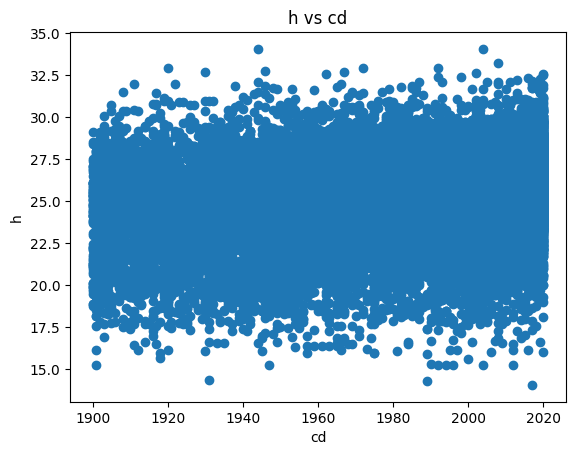

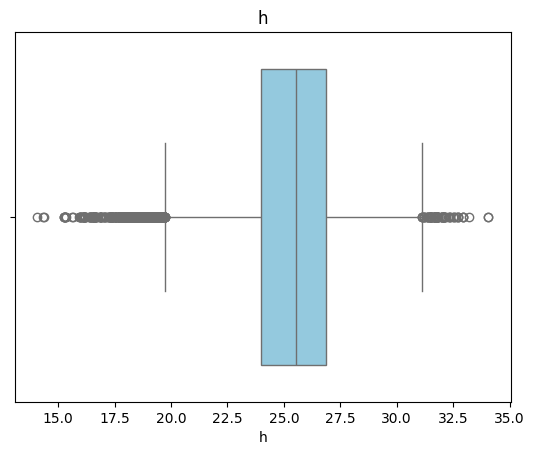

In [ ]:
#Vamos a seleccionar las lineas que tienen valores nulos
h_nulos=[]
for i in range(len(df_temp['h'])):
    if pd.isnull(df_temp['h'].iloc[i]): # Con pd.isnull() e.iloc obtengo los indices de esas lineas
        h_nulos.append(i)

print(h_nulos)
#print(df_temp.iloc[h_nulos])
print(df_temp[:].iloc[2575]) # asi accedo a alguna de esas lineas en particular.

#Vamos a graficar la relación de h con el tiempo
plot_scatter(df_temp['cd'],df_temp['h'])


#Boxplot de la variable h para visualizar outliers
plot_boxplot(df_temp['h'])



In [ ]:
# Cálculo del rango intercuartílico (IQR) y los limites inferiores y superiores de h

IQR_h, liminf_h, limsup_h=calcula_IQR(df_temp['h'])

# Identificamos outliers según h
outliers = df_temp[(df_temp['h'] < liminf_h) | (df_temp['h'] > limsup_h)]

print('el rango intercuartilico es: ',IQR_h)
print(f"Cantidad de outliers detectados en 'h': {len(outliers)}")
outliers_h=outliers['h']
# outliers_h.head()

el rango intercuartilico es:  2.850999999999999
Cantidad de outliers detectados en 'h': 803


🔢 En principio, los outliers de la variable `h` van a ser eliminados, a fin de simplificar las pruebas en el modelo. Queda pendiente para futuros experimentos reentrenar los modelos pero incluyendo estos datos, pues podrían estar conteniendo información válida a pesar de sus valores atípicos.

Ahora vamos a evaluar la variable `dist`, `dist_min` y `dist_max`

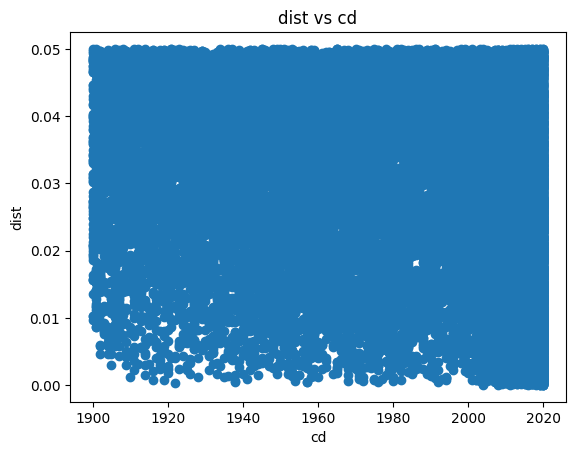

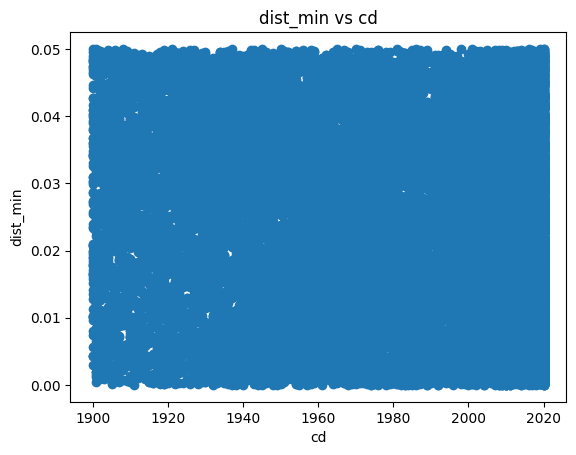

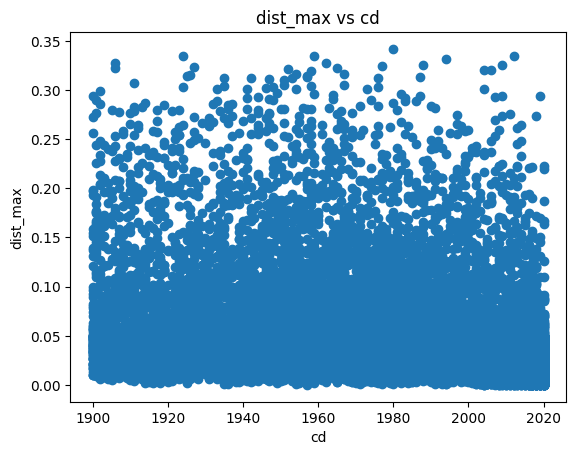

In [ ]:
#Vamos a graficar la relacion de dist con el tiempo:
plot_scatter(df_temp['cd'],df_temp['dist'])
plot_scatter(df_temp['cd'],df_temp['dist_min'])
plot_scatter(df_temp['cd'],df_temp['dist_max'])

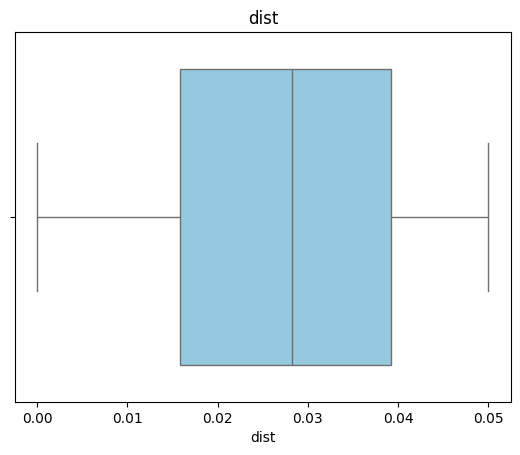

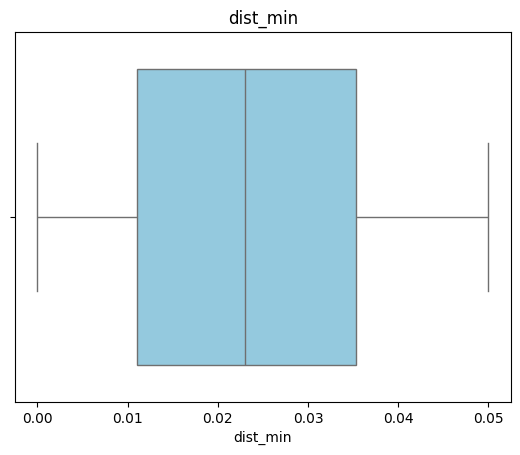

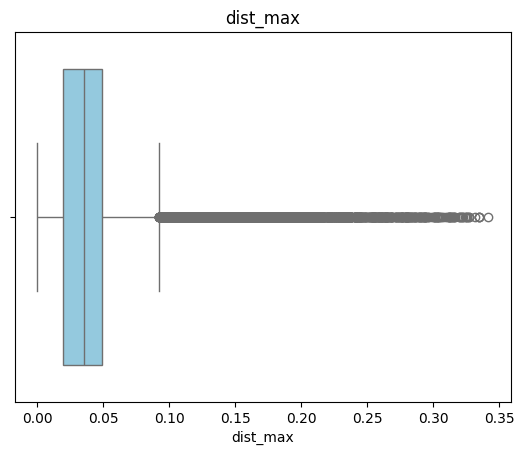

In [ ]:
#Boxplot de la variable dist para visualizar outliers
plot_boxplot(df_temp['dist'])
plot_boxplot(df_temp['dist_min'])
plot_boxplot(df_temp['dist_max'])

Vamos a analizar las variables de velocidades: v_rel; v_inf

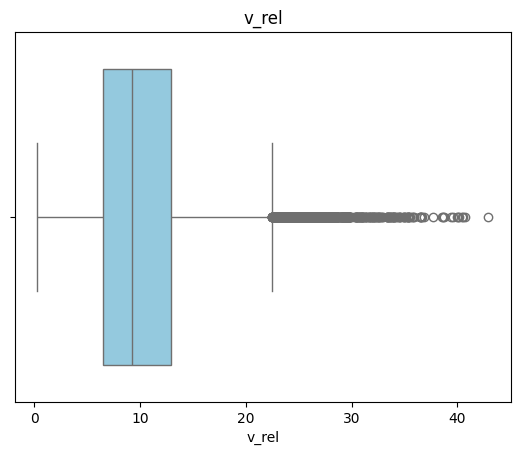

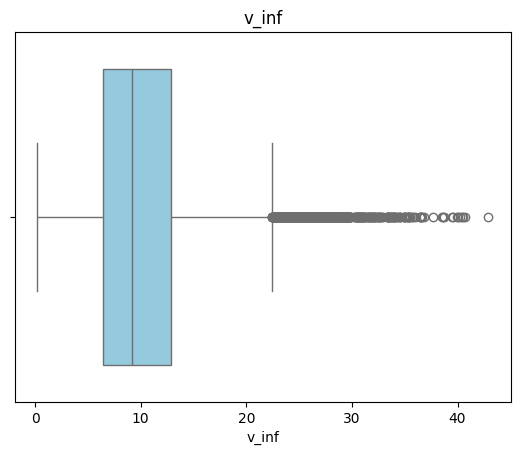

In [ ]:
plot_boxplot(df_temp['v_rel'])
plot_boxplot(df_temp['v_inf'])

Vamos a obtener los outliers de v_rel

In [ ]:
# Cálculo del IQR, limite inferior y superior de v_rel:
IQR_v, liminf_v, limsup_v=calcula_IQR(df_temp['v_rel'])

# Identificamos outliers
outliers = df_temp[(df_temp['v_rel'] < liminf_v) | (df_temp['v_rel'] > limsup_v)]

# Identificamos outliers
print('el rango intercuartilico es: ',IQR_v)
print(f"Cantidad de outliers detectados en 'v_rel': {len(outliers)}")
outliers_v=outliers['v_rel']
outliers_v.head()

el rango intercuartilico es:  6.404336729803601
Cantidad de outliers detectados en 'v_rel': 681


,v_rel
15,27.746286
51,26.719628
54,24.623718
55,27.845269
64,24.162981


Pareciera que las velocidades son iguales entre si (es decir que v_inf=v_rel para cada objeto)

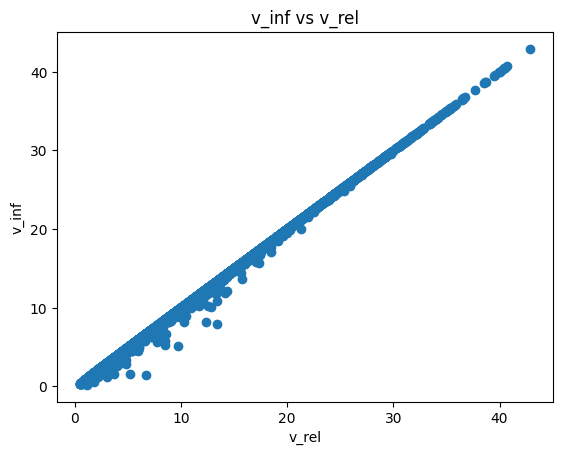

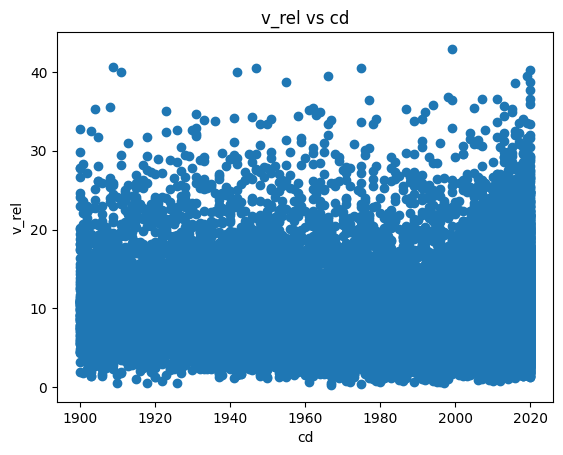

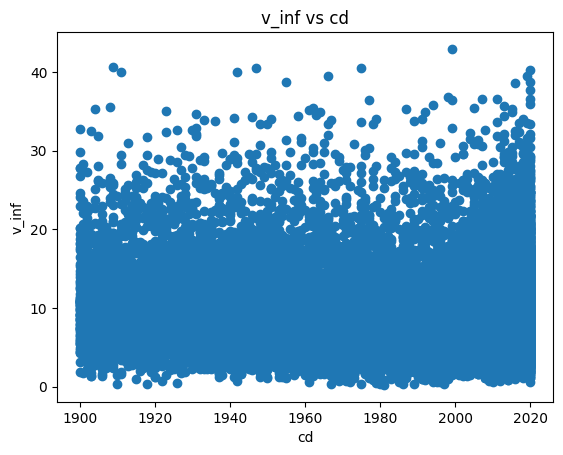

In [ ]:
plot_scatter(df_temp['v_rel'], df_temp['v_inf'])
plot_scatter(df_temp['cd'],df_temp['v_rel'])
plot_scatter(df_temp['cd'],df_temp['v_inf'])

Pareciera que para las velocidades de aproximacion (v_rel) mas bajas, hay una aceleracion respecto de su velocidad en el infinito. Luego la variacion se puede despreciar. Quizas se deba a un efecto de aceleración por el campo gravitatorio de la Tierra.

Evaluemos las relaciones entre distancias y velocidades:

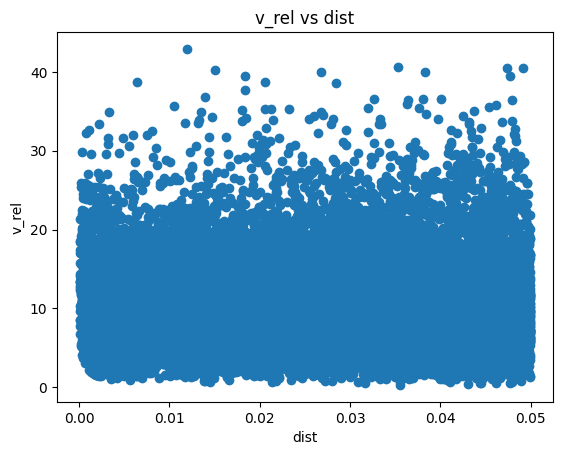

In [ ]:
plot_scatter(df_temp['dist'], df_temp['v_rel'])

## Correlación entre variables numéricas

A fin de aportar otra perspectiva sobre el dataset es analizar la correlación entre variables numéricas. Para ello vamos a calcular una matriz de correlación para las variables candidatas.

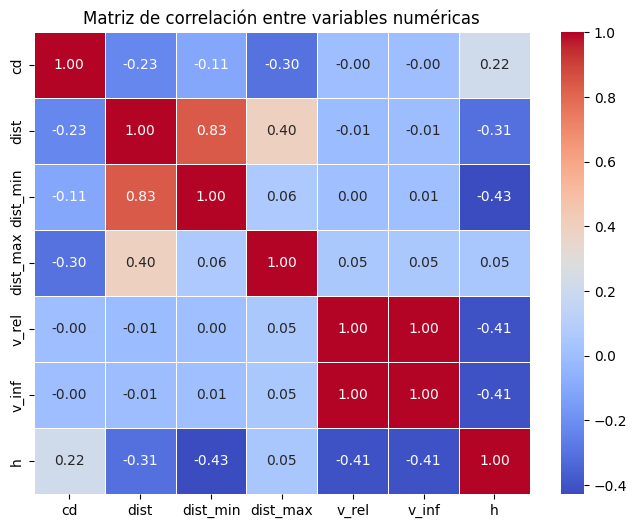

In [ ]:
# Seleccionamos las variables candidatas
variables_correlacion = df_temp[columnas_interes]

# Calculamos la matriz de correlación
matriz_correlacion = variables_correlacion.corr()

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

# **Conclusión EDA**


---

✅ Las variables `v_inf` y `v_rel` se correlacionan de forma absoluta, de manera que podría pensarse que son la misma. Por ello, a fin de evitar que el modelo sea entrenado con variables demasiado relacionadas solo consideraremos `v_rel` para el posterior desarrollo del trabajo.

✅ Las variables `dist_min` y `dist` presentan una alta correlación entre sí, por ello, para tambien evitar sesgos en el entrenamiento, la variable `dist` será descartada, mientras que `dist_min` va a ser la **variable objetivo**.

# Creación de variables de interés

🌄 De forma accesoria, puede resultar interesante evaluar cantidad de observaciones por año, a priori podríamos esperar una curva que crece para alcanzar un plateau

In [ ]:
#cantidad de objetos por año:
canti_anual=df_temp['cd'].value_counts()
print(canti_anual)

cd
2020    1510
2019    1222
2018     952
2017     943
2016     811
        ... 
1913      85
1914      84
1924      84
1917      75
1921      68
Name: count, Length: 121, dtype: int64


AttributeError: 'numpy.ndarray' object has no attribute 'name'

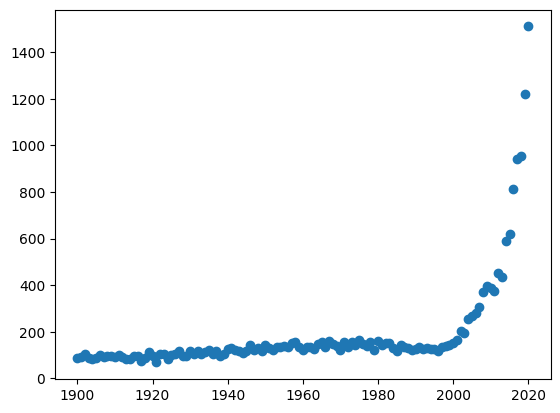

In [ ]:
# type(canti_anual)
# print(canti_anual)
# print(canti_anual.index)
# print(canti_anual.values)
plot_scatter(canti_anual.index,canti_anual.values)

🔭 Claramente hay un cambio a partir del siglo XXI en el que la detección de estos objetos crece de forma exponencial, posiblemente asociado al aumento de capacidades, infraestructura y tecnología disponible. Etse resultado contradice la hipotesis preliminar, lo que tambien plantea nuevas preguntas que podrían ser evaluadas en posteriores análisis.

#**Determinación de las variables de interes a implementar**

En base a los análisis realizados y las conclusiones anteriores, vamos a crear un arreglo final de variables que contiene a: `cd`, `d_min`, `d_max`, `v_rel` y `h`.

In [ ]:
df_trabajo=df_temp[['cd','dist_min','dist_max','v_rel','h']]
df_trabajo.head()

#tamaño del data frame:
print(f"el dataframe seleccionado tiene {df_trabajo.shape[0]} filas y {df_trabajo.shape[1]} columnas")

el dataframe seleccionado tiene 22947 filas y 5 columnas


In [ ]:
#Ahora vamos a elimianar las filas que corresponden a los outliers de la variable h:
df_trabajo=df_trabajo.drop(outliers_h.index)

#tamaño del data frame:
print(f"el dataframe seleccionado tiene {df_trabajo.shape[0]} filas y {df_trabajo.shape[1]} columnas")


el dataframe seleccionado tiene 22144 filas y 5 columnas


In [ ]:
#Ahora vamos a elimianar las filas que corresponden a los outliers de la variable v_rel:
df_trabajo=df_trabajo.drop(outliers_v.index, errors='ignore') #ignore es por si le pedimos borrar lineas que ya han sido borradas

#tamaño del data frame:
print(f"el dataframe seleccionado tiene {df_trabajo.shape[0]} filas y {df_trabajo.shape[1]} columnas")

el dataframe seleccionado tiene 21624 filas y 5 columnas


Ahora el dataframe `df_trabajo` esta listo sin outliers en aquellas variables que los tenian.

# Variables predictoras

Para el desarrollo subsiguiente del proyecto, nuestra variable objetivo va a ser `d_min`

Separamos entonces la variable objetivo de las predictoras

In [ ]:
# Separamos la variable objetivo
y = df_trabajo["dist_min"]

# Separamos las variables predictoras
X = df_trabajo.drop(columns=["dist_min"])

# Verificamos las dimensiones
print("Dimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

Dimensiones de X:
(21624, 4)

Dimensiones de y:
(21624,)


Revisamos nuevamente el tipo de datos que tenemos en los datos predictores:

In [ ]:
# Identificamos columnas numéricas dentro de X
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identificamos columnas categóricas dentro de X
columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas predictoras:")
print(columnas_numericas)

print("\nColumnas categóricas predictoras:")
print(columnas_categoricas)

Columnas numéricas predictoras:
['dist_max', 'v_rel', 'h']

Columnas categóricas predictoras:
[]


Todas las columnas son numéricas, lo cual es una ventaja.

# Escalado de variables

Al ser todas variables numéricas vamos a aplicar el método `StandardScaler`

In [ ]:
# Definimos el preprocesamiento para columnas numéricas y categóricas
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas)
    ]
)

#preprocesamiento

# Separación del dataset:

Vamos a separar el conjunto de datos totales entre un conjunto de entrenamiento, que se usará para que el modelo aprenda y un conjunto de prueba, que se usará más adelante para evaluar qué tan bien funciona el modelo con datos que no vio durante el entrenamiento. La relación será de 80% de los datos para entrenamiento y un 20% para prueba.

In [ ]:
# Dividimos las variables predictoras y la variable objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostramos las dimensiones resultantes
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (17299, 4)
Dimensiones de X_test: (4325, 4)
Dimensiones de y_train: (17299,)
Dimensiones de y_test: (4325,)


# Construcción del pipeline

In [ ]:
# En nuestor trabajo todas las columnas son numericas, por ello:
# Transformador para variables numéricas
transformador_numerico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler())
    ]
)

print("Transformador numérico creado:")
print(transformador_numerico)

Transformador numérico creado:
Pipeline(steps=[('imputador', SimpleImputer(strategy='median')),
                ('escalador', StandardScaler())])


In [ ]:
# Construimos el preprocesador general
preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", transformador_numerico, columnas_numericas) #X = columnas_numericas_modelo en mi caso --> cambiar a lista de columnas
    ]
)

print("Preprocesador creado:")
print(preprocesamiento)

Preprocesador creado:
ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalador',
                                                  StandardScaler())]),
                                 ['dist_max', 'v_rel', 'h'])])


# Entrenamiento de modelos: regresión logística

Este modelo no es el apropiado porque según el tipo de datos lo mejor sería una regresión lineal. LÑa regresión logísitica es mas adecuada para un problema de clasificación.

In [ ]:
# Creamos el pipeline completo con Regresión Logística
pipeline_lineal = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Entrenamos el modelo con los datos de entrenamiento
pipeline_lineal.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

# Entrenamiento de modelos: regresión lineal

In [ ]:
# Creamos el pipeline completo con Regresión Logística
pipeline_lineal = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", LinearRegression()) #max_iter=1000,random_state=42
    ]
)

# Entrenamos el modelo con los datos de entrenamiento
pipeline_lineal.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


Ya entrenamos el primer modelo del proyecto: una Regresión lineal.

Este modelo recibió como entrada el conjunto de entrenamiento X_train y aprendió a relacionar las variables numericas con la variable objetivo y_train, que indica la distancia minima a la que objetos estelares se acercan a la tierra.

Como el pipeline incluye tanto el preprocesamiento como el modelo, al ejecutar fit() ocurrieron dos cosas:

primero se aplicaron las transformaciones necesarias sobre los datos de entrenamiento;
luego se entrenó la Regresión lineal con esos datos ya preparados.

# Predicciones con el modelo de Regresión lineal
Una vez entrenado el modelo, podemos usarlo para realizar predicciones sobre el conjunto de prueba.

En la siguiente celda vamos a generar las predicciones de la Regresión lineal sobre X_test y las guardaremos en una variable llamada y_pred_lineal.

Luego compararemos esas predicciones con los valores reales de y_test.

Primeras predicciones del modelo:
[0.02659972 0.02428471 0.02567735 0.02386935 0.02557615 0.0215974
 0.02414114 0.02486653 0.01835489 0.02457788]

Primeros valores reales:
[0.03882057 0.02099099 0.03925821 0.02406031 0.03841726 0.02874163
 0.01359643 0.02470012 0.00587058 0.012605  ]


Text(0.5, 1.0, 'Comparación entre valores reales y predicciones')

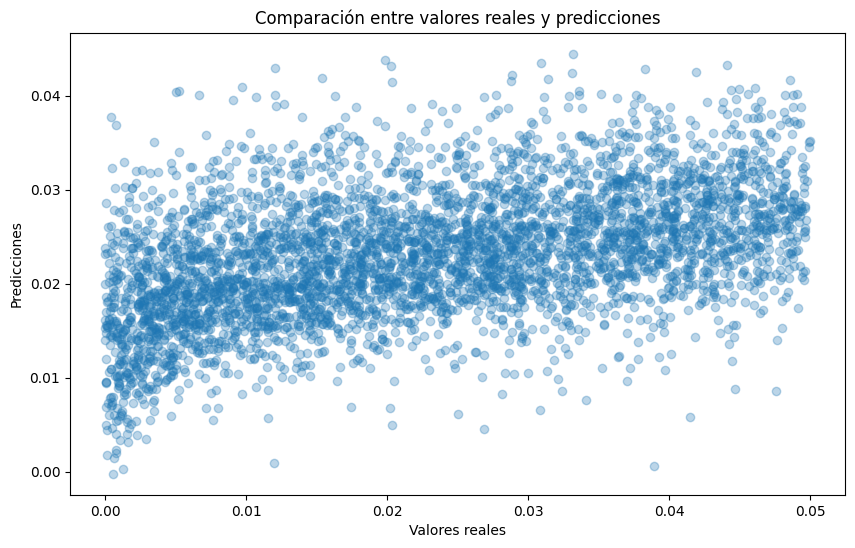

In [ ]:
# Generamos predicciones sobre el conjunto de prueba
y_pred_lineal = pipeline_lineal.predict(X_test)

# Mostramos las primeras predicciones
print("Primeras predicciones del modelo:")
print(y_pred_lineal[:10])

print("\nPrimeros valores reales:")
print(y_test.values[:10])

# para una mejor comparación, graficamos:
plt.figure(figsize=(10, 6))
plt.scatter(y_test.values, y_pred_lineal, alpha=0.3)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Comparación entre valores reales y predicciones")

#Otra buena opción para evaluar a priori estos resultados podría ser
# graficar la resta entre el valor empirico y el calculado.

En principio la relacion lineal entre variable empirica y la prediccion parece ser un indicador positivo.

Evaluación del modelo de Regresión lineal
Ahora vamos a evaluar el rendimiento del modelo sobre el conjunto de prueba.

Para eso calcularemos dos métricas principales:

MAE:

R2:


In [ ]:
# calcular R2 y MAE y demas parametros de rendimiento del modelo.